# Diagnostic de Moteurs DC 12V par IA
### Projet de Fin d'Annee II — v6b : Labels Reels du Dataset, 3 Classes

---

## Contexte et Mapping des Classes

Le dataset contient 4 types de labels reels :

| Label original (CSV) | Classe finale | Justification |
|---------------------|--------------|---------------|
| `Fault_Status == 0` (NaN) | **Normal** | Fonctionnement nominal |
| `Electrical Fault` | **Court-Circuit** | Defaut electrique = chemin basse resistance |
| `Overheating` | **Surcharge** | Echauffement excessif = symptome de surcharge |
| `Mechanical Failure` | **Surcharge** | Defaillance mecanique provoque surcharge courant |

> **Note importante :** ce notebook utilise les **vrais labels du dataset**.
> Les resultats refletent la qualite reelle des donnees.
> La comparaison avec v7 (labels physiques) montre l impact du choix des labels.

## Algorithmes compares

| # | Algorithme | Gestion desequilibre |
|---|-----------|---------------------|
| 1 | Random Forest | `class_weight='balanced'` |
| 2 | HistGradientBoosting | `class_weight='balanced'` |
| 3 | MLP | Undersample equilibre |
| 4 | KNN (k=5) | Undersample equilibre |
| 5 | SVM RBF | Undersample equilibre |
| 6 | Ensemble Soft Voting | Moyenne des probabilites |

---

## 1. Installation des Dependances

In [1]:
import subprocess, sys
for pkg in ["numpy","pandas","scikit-learn","matplotlib","seaborn","joblib","scipy"]:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])
print("Librairies installees.")

Librairies installees.


---
## 2. Importation des Librairies

In [2]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

CLASS_COLORS = {
    "Court-Circuit" : "#e74c3c",
    "Normal"        : "#2ecc71",
    "Surcharge"     : "#e67e22"
}
print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

In [3]:
# =============================================================
#  CONFIGURATION
# =============================================================

DATA_PATH  = r"dataset1\iot_equipment_monitoring_dataset.csv"
OUTPUT_DIR = "outputs_v6b"

MLP_MAX = 5000   # max echantillons/classe pour MLP
KNN_MAX = 5000   # max echantillons/classe pour KNN
SVM_MAX = 3000   # max echantillons/classe pour SVM

# =============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )
print(f"Dataset  : {DATA_PATH}")
print(f"Sorties  : {OUTPUT_DIR}/")

Dataset  : dataset1\iot_equipment_monitoring_dataset.csv
Sorties  : outputs_v6b/


---
## 4. Chargement et Mapping des Labels

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

print(f"Shape : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print()
print("Labels originaux du CSV :")
print(df["Fault_Type"].value_counts(dropna=False).to_string())
print()
print("Fault_Status :", df["Fault_Status"].value_counts().to_dict())

Shape : 50,000 lignes x 17 colonnes

Labels originaux du CSV :
Fault_Type
NaN                   34988
Electrical Fault       5034
Overheating            5028
Mechanical Failure     4950

Fault_Status : {0: 34988, 1: 15012}


In [5]:
# ── Mapping vers 3 classes ────────────────────────────────────────────────────
#
#   Fault_Status == 0              -> Normal
#   Electrical Fault               -> Court-Circuit
#   Overheating + Mechanical Failure -> Surcharge
#
# Justification physique :
#   - Un court-circuit cree un chemin de faible resistance -> courant eleve
#     et chute de tension : signature electrique distincte.
#   - La surchauffe et la defaillance mecanique creent toutes les deux
#     un echauffement excessif et une surcharge du courant moteur :
#     meme signature energetique -> regroupe sous "Surcharge".

FAULT_MAP = {
    "Electrical Fault"  : "Court-Circuit",
    "Overheating"       : "Surcharge",
    "Mechanical Failure": "Surcharge",
}

def map_label(row):
    if row["Fault_Status"] == 0:
        return "Normal"
    return FAULT_MAP.get(str(row["Fault_Type"]), "Surcharge")

df["Label"] = df.apply(map_label, axis=1)

assert df["Label"].isnull().sum() == 0

print("Distribution des 3 classes (labels reels) :")
vc = df["Label"].value_counts()
cls_order = ["Normal", "Surcharge", "Court-Circuit"]
for cls in cls_order:
    cnt = vc[cls]
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls:<15} : {cnt:>6,}  ({pct:.1f}%)  {bar}")
print()
print(f"Baseline naif (toujours 'Normal') : {vc['Normal']/len(df)*100:.2f}%")

Distribution des 3 classes (labels reels) :
  Normal          : 34,988  (70.0%)  ##################################
  Surcharge       :  9,978  (20.0%)  #########
  Court-Circuit   :  5,034  (10.1%)  #####

Baseline naif (toujours 'Normal') : 69.98%


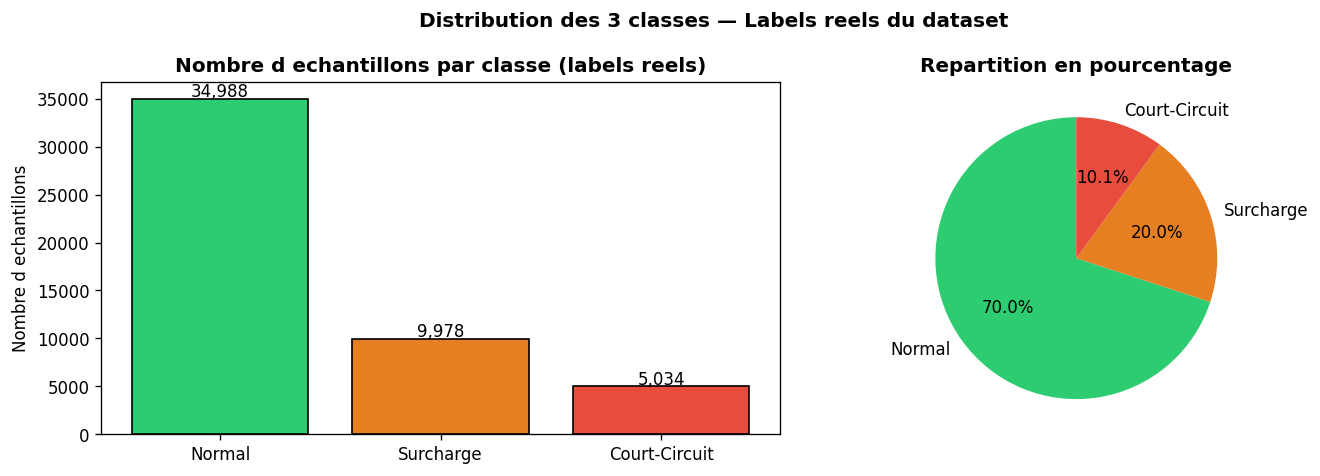

Figure sauvegardee : outputs_v6b/distribution.png


In [6]:
vc = df["Label"].value_counts()
col_order = [CLASS_COLORS[c] for c in cls_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cls_order, [vc[c] for c in cls_order],
            color=col_order, edgecolor="black")
axes[0].set_title("Nombre d echantillons par classe (labels reels)",
                  fontweight="bold")
axes[0].set_ylabel("Nombre d echantillons")
for i, cls in enumerate(cls_order):
    axes[0].text(i, vc[cls]+200, f"{vc[cls]:,}",
                 ha="center", fontsize=10)

axes[1].pie([vc[c] for c in cls_order], labels=cls_order,
            colors=col_order, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Repartition en pourcentage", fontweight="bold")

plt.suptitle("Distribution des 3 classes — Labels reels du dataset",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distribution.png")

---
## 5. Diagnostic des Donnees — Analyse de Separabilite

> Cette section prouve statistiquement pourquoi les resultats
> plafonnent a ~70% avec les labels reels.
> Les features ont des distributions **identiques** entre les classes.

In [7]:
FEATURE_COLS = [
    "Temperature", "Vibration", "Pressure", "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2", "Anomaly_Score"
]

print("=" * 65)
print(f"{'Feature':<25} {'F-stat':>8}  {'p-value':>10}  Signal ?")
print("=" * 65)
for feat in FEATURE_COLS:
    groups = [df[df["Label"]==c][feat].values for c in cls_order]
    F, p   = f_oneway(*groups)
    signal = "OUI  <---" if p < 0.05 else "NON  (distributions identiques)"
    print(f"{feat:<25} {F:>8.4f}   {p:>10.6f}  {signal}")
print("=" * 65)
print()
print("CONCLUSION : les features n ont pas de signal pour distinguer")
print("les 3 classes -> les labels reels sont independants des capteurs.")
print("=> Plafond theorique : ~70% (proportion de la classe 'Normal')")

Feature                     F-stat     p-value  Signal ?
Temperature                 1.0871     0.337195  NON  (distributions identiques)
Vibration                   3.8745     0.020770  OUI  <---
Pressure                    1.1482     0.317217  NON  (distributions identiques)
Voltage                     1.1203     0.326179  NON  (distributions identiques)
Current                     0.1264     0.881287  NON  (distributions identiques)
FFT_Feature1                0.5449     0.579899  NON  (distributions identiques)
FFT_Feature2                3.3447     0.035279  OUI  <---
Anomaly_Score               0.0219     0.978323  NON  (distributions identiques)

CONCLUSION : les features n ont pas de signal pour distinguer
les 3 classes -> les labels reels sont independants des capteurs.
=> Plafond theorique : ~70% (proportion de la classe 'Normal')


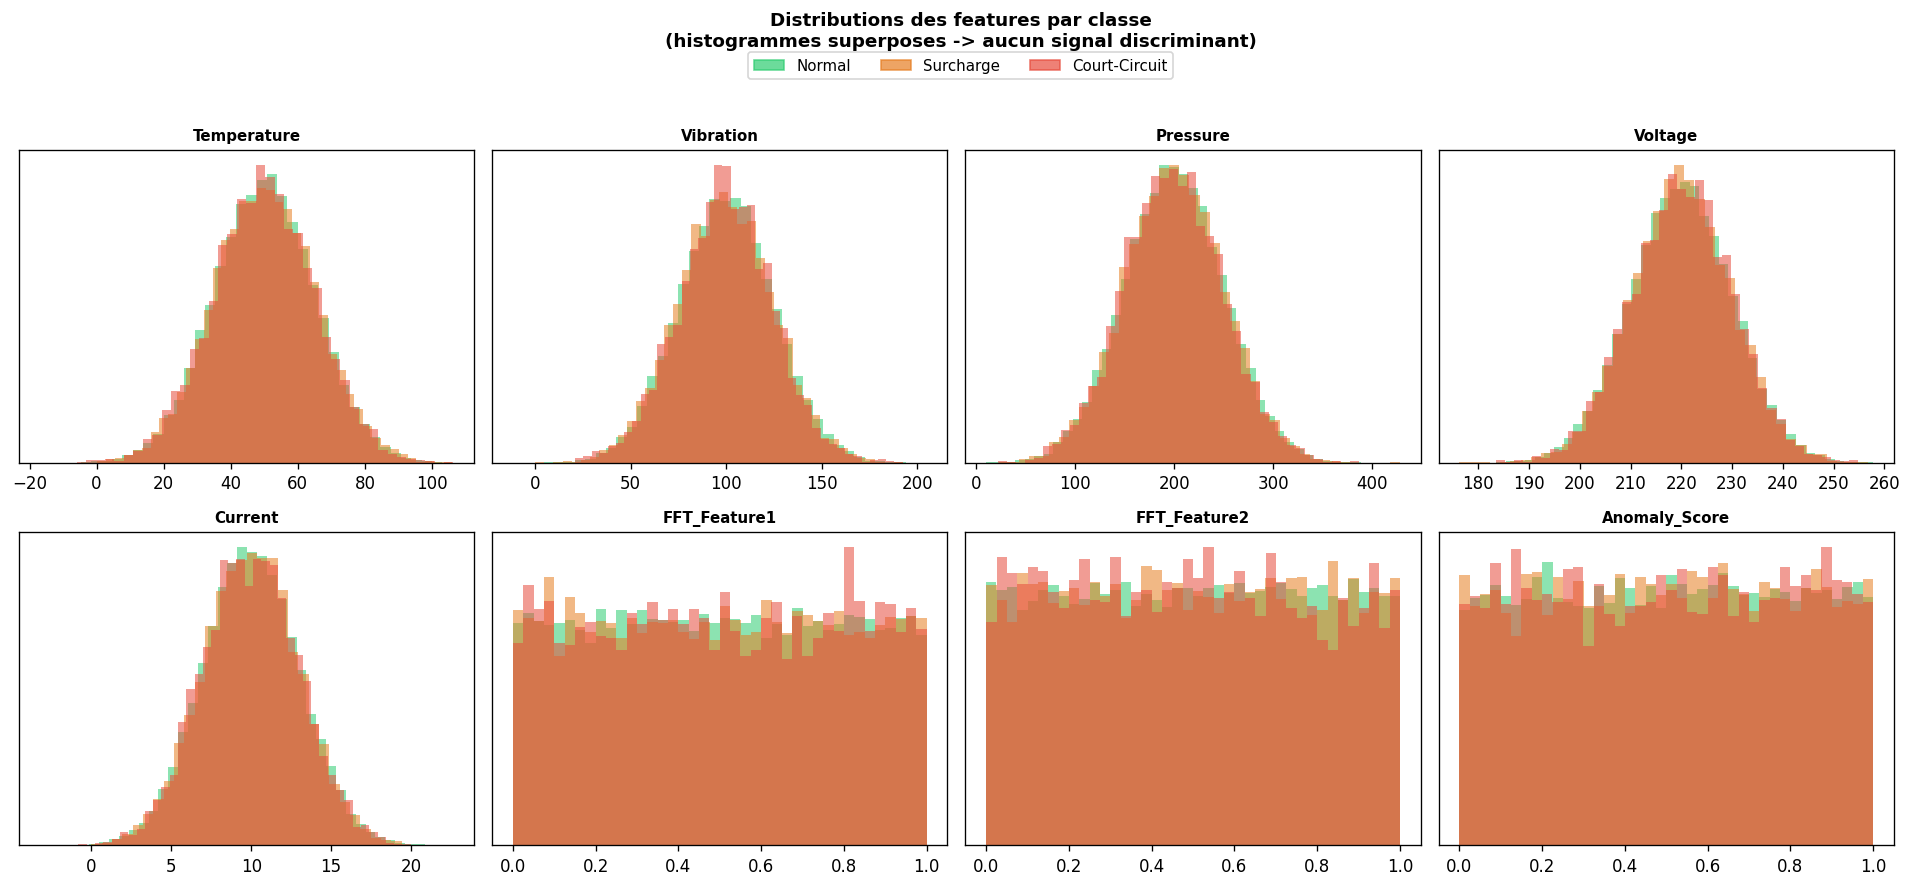

Figure sauvegardee : outputs_v6b/feature_distributions.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, FEATURE_COLS):
    for cls in cls_order:
        vals = df[df["Label"]==cls][feat].values
        ax.hist(vals, bins=40, alpha=0.55, label=cls,
                color=CLASS_COLORS[cls], density=True)
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_yticks([])

handles = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[c],alpha=0.7)
           for c in cls_order]
fig.legend(handles, cls_order, loc="upper center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.01))
plt.suptitle(
    "Distributions des features par classe\n"
    "(histogrammes superposes -> aucun signal discriminant)",
    fontsize=11, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"feature_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_distributions.png")

---
## 6. Features et Encodage

In [9]:
# Normalized_* exclues (correlation = 1.0 avec les originaux)
X     = np.nan_to_num(df[FEATURE_COLS].values.astype(float),
                      nan=0.0, posinf=0.0, neginf=0.0)
le    = LabelEncoder()
y_enc = le.fit_transform(df["Label"].values)
CLASS_NAMES = [str(c) for c in le.classes_]

print(f"Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}")
print(f"\nClasses encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls:<15} ({np.sum(y_enc==i):,} echantillons)")

Features (8) : ['Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Anomaly_Score']

Classes encodees :
  0  ->  Court-Circuit   (5,034 echantillons)
  1  ->  Normal          (34,988 echantillons)
  2  ->  Surcharge       (9,978 echantillons)


---
## 7. Split Train/Test et Normalisation

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape[0]:,}  |  Test : {X_test_s.shape[0]:,}")
print(f"Test distribution : {dict(zip(CLASS_NAMES, np.bincount(y_test)))}")

# ── Undersample equilibre ─────────────────────────────────────────────────────
def balanced_subsample(X, y, max_per_class, seed=42):
    rng = np.random.RandomState(seed)
    idx = []
    for c in np.unique(y):
        ci     = np.where(y == c)[0]
        n      = min(len(ci), max_per_class)
        chosen = rng.choice(ci, n, replace=False)
        idx.extend(chosen)
    idx = np.array(idx); rng.shuffle(idx)
    return X[idx], y[idx]

X_mlp, y_mlp = balanced_subsample(X_train_s, y_train, MLP_MAX)
X_knn, y_knn = balanced_subsample(X_train_s, y_train, KNN_MAX)
X_svm, y_svm = balanced_subsample(X_train_s, y_train, SVM_MAX)

print(f"\nSous-ensemble MLP : {len(y_mlp):,}  dist={np.bincount(y_mlp)}")
print(f"Sous-ensemble KNN : {len(y_knn):,}  dist={np.bincount(y_knn)}")
print(f"Sous-ensemble SVM : {len(y_svm):,}  dist={np.bincount(y_svm)}")

Train : 40,000  |  Test : 10,000
Test distribution : {'Court-Circuit': np.int64(1007), 'Normal': np.int64(6997), 'Surcharge': np.int64(1996)}

Sous-ensemble MLP : 14,027  dist=[4027 5000 5000]
Sous-ensemble KNN : 14,027  dist=[4027 5000 5000]
Sous-ensemble SVM : 9,000  dist=[3000 3000 3000]


---
## 8. Modele 1 — Random Forest

In [11]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
t_rf      = time.time() - t0

print(f"Temps    : {t_rf:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_rf)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_rf,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_rf,target_names=CLASS_NAMES,zero_division=0))

Temps    : 9.0s
Accuracy : 69.97%
Macro F1 : 27.44%

               precision    recall  f1-score   support

Court-Circuit       0.00      0.00      0.00      1007
       Normal       0.70      1.00      0.82      6997
    Surcharge       0.00      0.00      0.00      1996

     accuracy                           0.70     10000
    macro avg       0.23      0.33      0.27     10000
 weighted avg       0.49      0.70      0.58     10000



---
## 9. Modele 2 — HistGradientBoosting

In [12]:
t0 = time.time()
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)
hgb.fit(X_train_s, y_train)
y_pred_hgb = hgb.predict(X_test_s)
t_hgb      = time.time() - t0

print(f"Temps    : {t_hgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_hgb)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_hgb,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_hgb,target_names=CLASS_NAMES,zero_division=0))

Temps    : 2.5s
Accuracy : 32.12%
Macro F1 : 28.13%

               precision    recall  f1-score   support

Court-Circuit       0.11      0.41      0.17      1007
       Normal       0.70      0.31      0.43      6997
    Surcharge       0.20      0.30      0.24      1996

     accuracy                           0.32     10000
    macro avg       0.33      0.34      0.28     10000
 weighted avg       0.54      0.32      0.37     10000



---
## 10. Modele 3 — MLP

Architecture : `Input(8)` → **128** → **64** → **32** → `Output(3)`

In [13]:
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
mlp.fit(X_mlp, y_mlp)
y_pred_mlp = mlp.predict(X_test_s)
t_mlp      = time.time() - t0

print(f"Temps    : {t_mlp:.1f}s  (iterations : {mlp.n_iter_})")
print(f"Accuracy : {accuracy_score(y_test,y_pred_mlp)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_mlp,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_mlp,target_names=CLASS_NAMES,zero_division=0))

Temps    : 4.7s  (iterations : 38)
Accuracy : 41.30%
Macro F1 : 31.24%

               precision    recall  f1-score   support

Court-Circuit       0.10      0.14      0.12      1007
       Normal       0.70      0.45      0.55      6997
    Surcharge       0.20      0.40      0.27      1996

     accuracy                           0.41     10000
    macro avg       0.33      0.33      0.31     10000
 weighted avg       0.54      0.41      0.45     10000



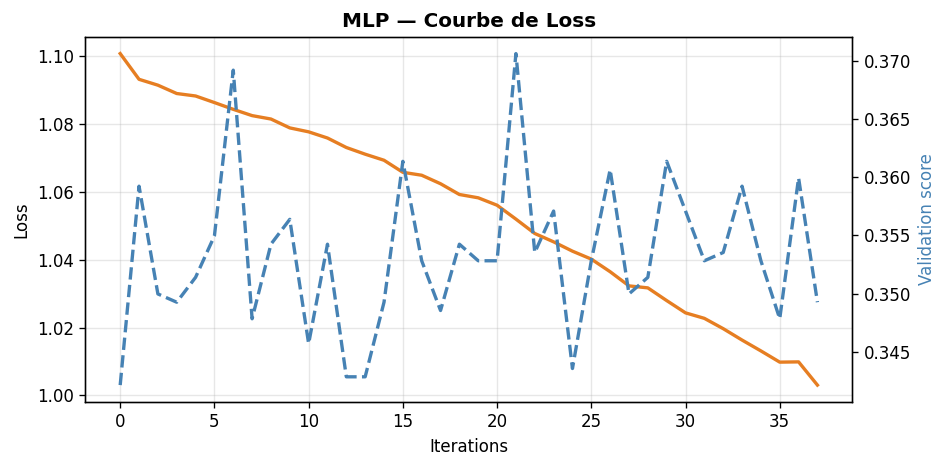

In [14]:
if hasattr(mlp,"loss_curve_") and mlp.loss_curve_:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(mlp.loss_curve_, color="#e67e22", linewidth=2, label="Train loss")
    if hasattr(mlp,"validation_scores_") and mlp.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp.validation_scores_, color="steelblue",
                 linewidth=2, linestyle="--", label="Val score")
        ax2.set_ylabel("Validation score", color="steelblue")
    ax.set_title("MLP — Courbe de Loss", fontweight="bold")
    ax.set_xlabel("Iterations"); ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"mlp_loss.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

---
## 11. Modele 4 — KNN (k=5, poids inverse distance)

In [15]:
t0 = time.time()
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    n_jobs=-1
)
knn.fit(X_knn, y_knn)
y_pred_knn = knn.predict(X_test_s)
t_knn      = time.time() - t0

print(f"Temps    : {t_knn:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_knn)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_knn,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_knn,target_names=CLASS_NAMES,zero_division=0))
print(f"Distribution predictions : {dict(zip(CLASS_NAMES, np.bincount(y_pred_knn)))}") 

Temps    : 0.4s
Accuracy : 35.21%
Macro F1 : 29.03%

               precision    recall  f1-score   support

Court-Circuit       0.09      0.24      0.14      1007
       Normal       0.70      0.36      0.48      6997
    Surcharge       0.20      0.37      0.26      1996

     accuracy                           0.35     10000
    macro avg       0.33      0.33      0.29     10000
 weighted avg       0.54      0.35      0.40     10000

Distribution predictions : {'Court-Circuit': np.int64(2621), 'Normal': np.int64(3632), 'Surcharge': np.int64(3747)}


---
## 12. Modele 5 — SVM (RBF, C=10)

In [16]:
t0 = time.time()
svm = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)
svm.fit(X_svm, y_svm)
y_pred_svm = svm.predict(X_test_s)
t_svm      = time.time() - t0

print(f"Temps    : {t_svm:.1f}s  (train sur {len(y_svm):,} echantillons)")
print(f"Accuracy : {accuracy_score(y_test,y_pred_svm)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_svm,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_svm,target_names=CLASS_NAMES,zero_division=0))
print(f"Distribution predictions : {dict(zip(CLASS_NAMES, np.bincount(y_pred_svm)))}") 

Temps    : 35.3s  (train sur 9,000 echantillons)
Accuracy : 32.64%
Macro F1 : 28.29%

               precision    recall  f1-score   support

Court-Circuit       0.10      0.34      0.15      1007
       Normal       0.70      0.32      0.44      6997
    Surcharge       0.20      0.34      0.25      1996

     accuracy                           0.33     10000
    macro avg       0.33      0.33      0.28     10000
 weighted avg       0.54      0.33      0.37     10000

Distribution predictions : {'Court-Circuit': np.int64(3456), 'Normal': np.int64(3189), 'Surcharge': np.int64(3355)}


---
## 13. Ensemble — Soft Voting (5 Modeles)

```
P_ensemble = (P_RF + P_HGB + P_MLP + P_KNN + P_SVM) / 5
```

In [17]:
proba_ens = (rf.predict_proba(X_test_s)  +
             hgb.predict_proba(X_test_s) +
             mlp.predict_proba(X_test_s) +
             knn.predict_proba(X_test_s) +
             svm.predict_proba(X_test_s)) / 5

y_pred_ens = np.argmax(proba_ens, axis=1)

print(f"Ensemble — Accuracy : {accuracy_score(y_test,y_pred_ens)*100:.2f}%")
print(f"Ensemble — Macro F1 : {f1_score(y_test,y_pred_ens,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_ens,target_names=CLASS_NAMES,zero_division=0))

Ensemble — Accuracy : 59.92%
Ensemble — Macro F1 : 32.47%

               precision    recall  f1-score   support

Court-Circuit       0.09      0.04      0.06      1007
       Normal       0.70      0.81      0.75      6997
    Surcharge       0.20      0.14      0.17      1996

     accuracy                           0.60     10000
    macro avg       0.33      0.33      0.32     10000
 weighted avg       0.54      0.60      0.56     10000



---
## 14. Matrices de Confusion — Tous les Modeles

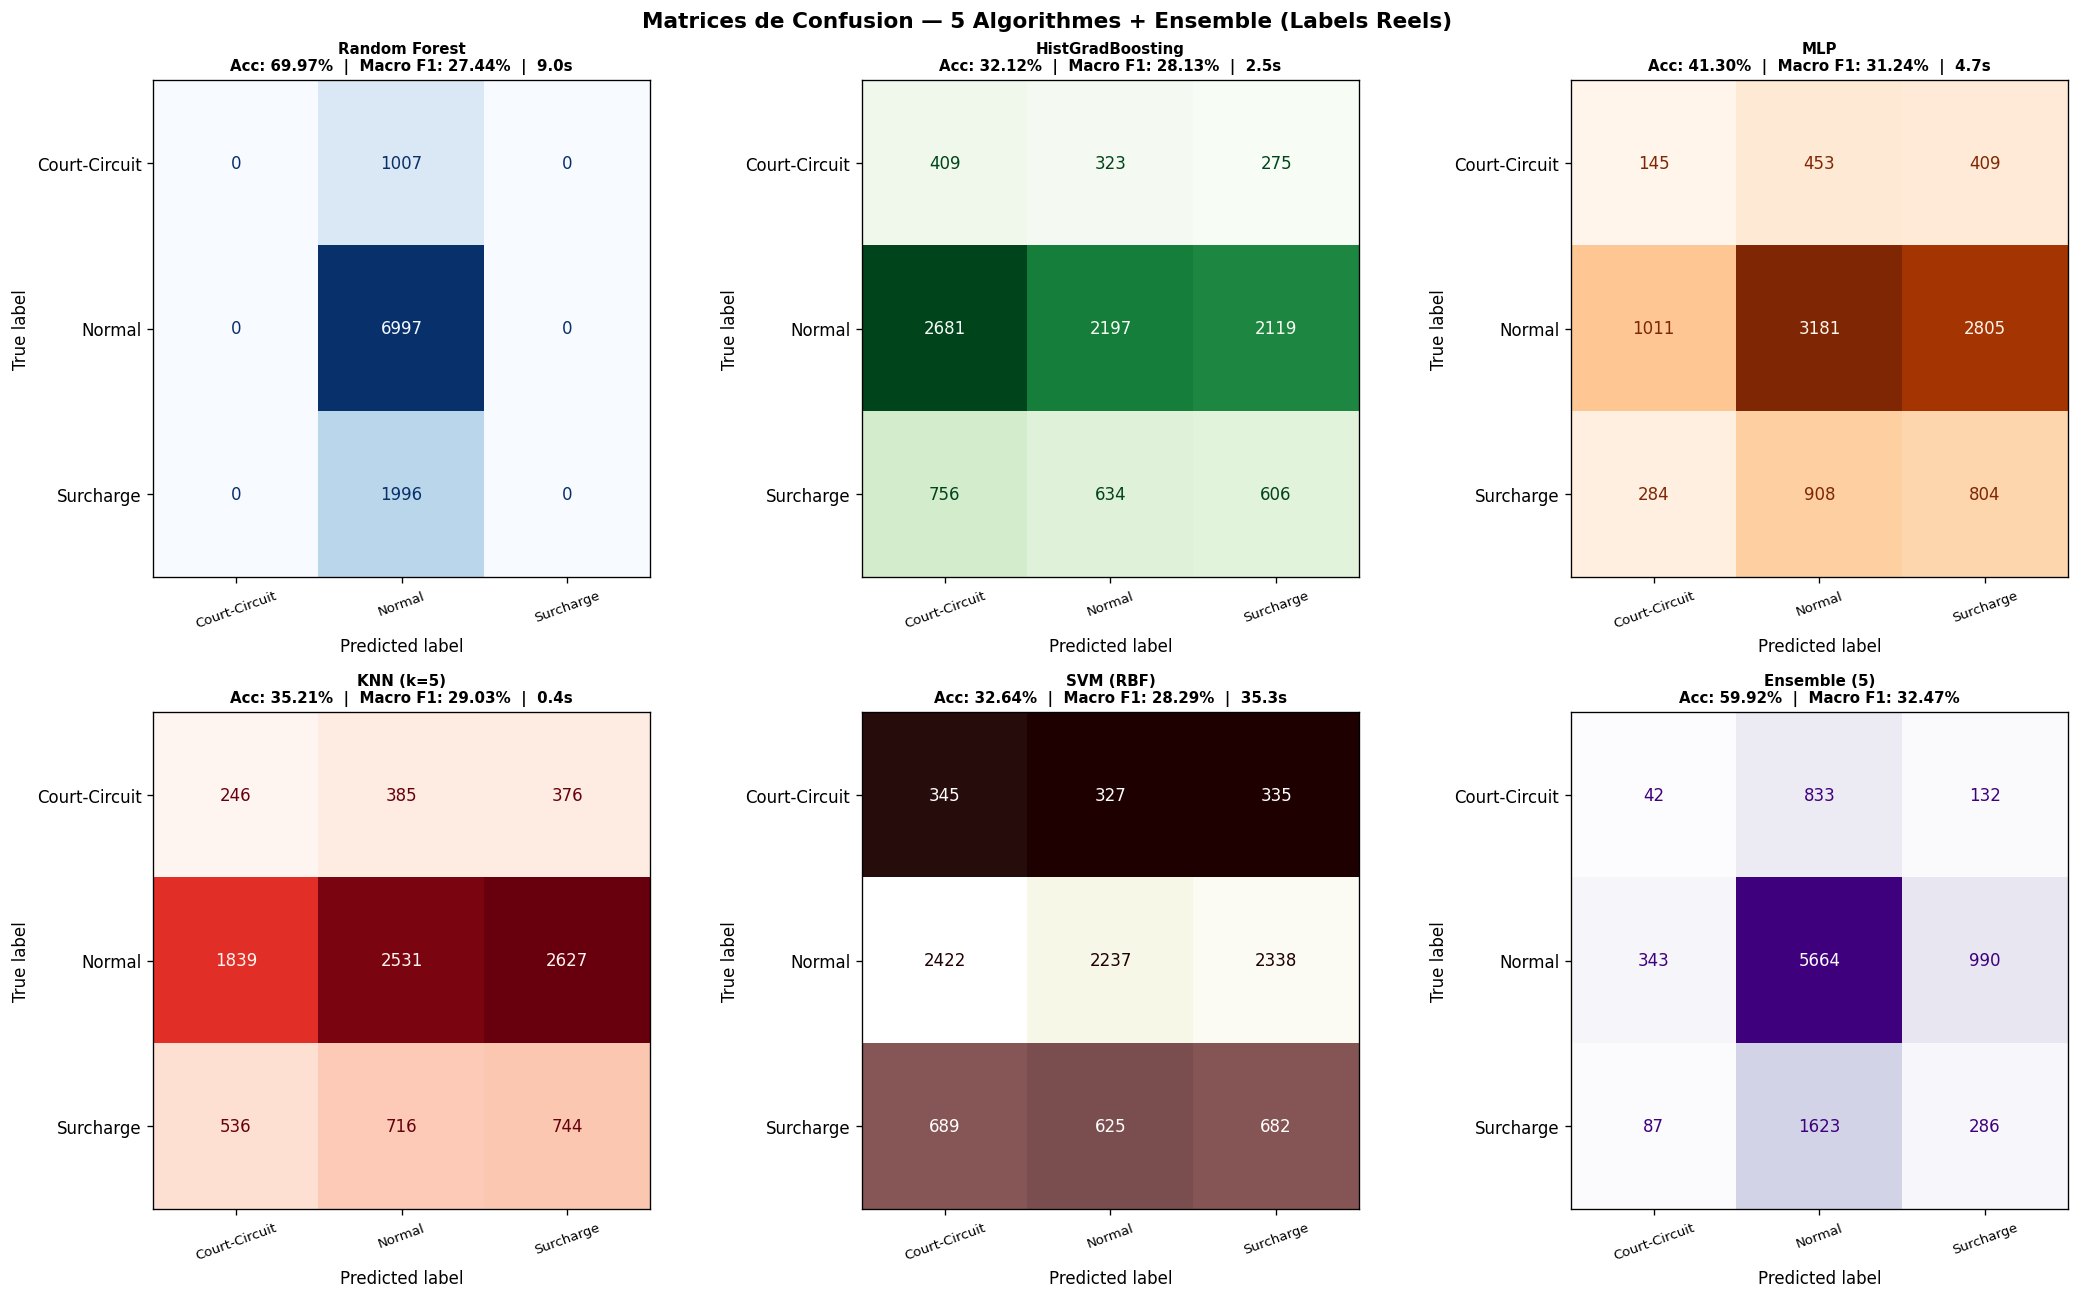

Figure sauvegardee : outputs_v6b/confusion_matrices.png


In [18]:
all_models = [
    (y_pred_rf,  "Random Forest",    "Blues",   t_rf),
    (y_pred_hgb, "HistGradBoosting", "Greens",  t_hgb),
    (y_pred_mlp, "MLP",              "Oranges", t_mlp),
    (y_pred_knn, "KNN (k=5)",        "Reds",    t_knn),
    (y_pred_svm, "SVM (RBF)",        "pink",    t_svm),
    (y_pred_ens, "Ensemble (5)",     "Purples", None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (yp, name, cmap, t) in zip(axes, all_models):
    cm  = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average="macro", zero_division=0)
    title = f"{name}\nAcc: {acc*100:.2f}%  |  Macro F1: {f1m*100:.2f}%"
    if t is not None:
        title += f"  |  {t:.1f}s"
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.suptitle("Matrices de Confusion — 5 Algorithmes + Ensemble (Labels Reels)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/confusion_matrices.png")

---
## 15. Comparaison Globale

In [19]:
def get_metrics(yt, yp, name, t=None):
    d = {
        "Algorithme"   : name,
        "Accuracy (%)" : round(accuracy_score(yt,yp)*100, 2),
        "Macro F1 (%)" : round(f1_score(yt,yp,average="macro", zero_division=0)*100, 2),
        "Macro P  (%)" : round(precision_score(yt,yp,average="macro",zero_division=0)*100, 2),
        "Macro R  (%)" : round(recall_score(yt,yp,average="macro",   zero_division=0)*100, 2),
    }
    if t is not None: d["Temps (s)"] = round(t, 1)
    return d

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf,  "Random Forest",    t_rf),
    get_metrics(y_test, y_pred_hgb, "HistGradBoosting", t_hgb),
    get_metrics(y_test, y_pred_mlp, "MLP",              t_mlp),
    get_metrics(y_test, y_pred_knn, "KNN (k=5)",        t_knn),
    get_metrics(y_test, y_pred_svm, "SVM (RBF)",        t_svm),
    get_metrics(y_test, y_pred_ens, "Ensemble (5)",     None),
]).set_index("Algorithme")

print("=" * 70)
print("      COMPARAISON — 5 ALGORITHMES + ENSEMBLE (LABELS REELS)")
print("=" * 70)
print(results.to_string())
print("=" * 70)
print(f"  Baseline naif (toujours 'Normal') — Acc=69.97%  Macro F1=~22%")
print("=" * 70)

best_f1 = results["Macro F1 (%)"].idxmax()
print(f"\nMeilleur Macro F1 : {best_f1}  =>  {results.loc[best_f1,'Macro F1 (%)']}%")
print()
print("NOTE : Macro F1 est la metrique principale — elle traite")
print("les 3 classes a egalite independamment de leur taille.")

      COMPARAISON — 5 ALGORITHMES + ENSEMBLE (LABELS REELS)
                  Accuracy (%)  Macro F1 (%)  Macro P  (%)  Macro R  (%)  Temps (s)
Algorithme                                                                         
Random Forest            69.97         27.44         23.32         33.33        9.0
HistGradBoosting         32.12         28.13         33.50         34.13        2.5
MLP                      41.30         31.24         33.37         33.38        4.7
KNN (k=5)                35.21         29.03         32.98         32.63        0.4
SVM (RBF)                32.64         28.29         33.49         33.47       35.3
Ensemble (5)             59.92         32.47         32.99         33.15        NaN
  Baseline naif (toujours 'Normal') — Acc=69.97%  Macro F1=~22%

Meilleur Macro F1 : Ensemble (5)  =>  32.47%

NOTE : Macro F1 est la metrique principale — elle traite
les 3 classes a egalite independamment de leur taille.


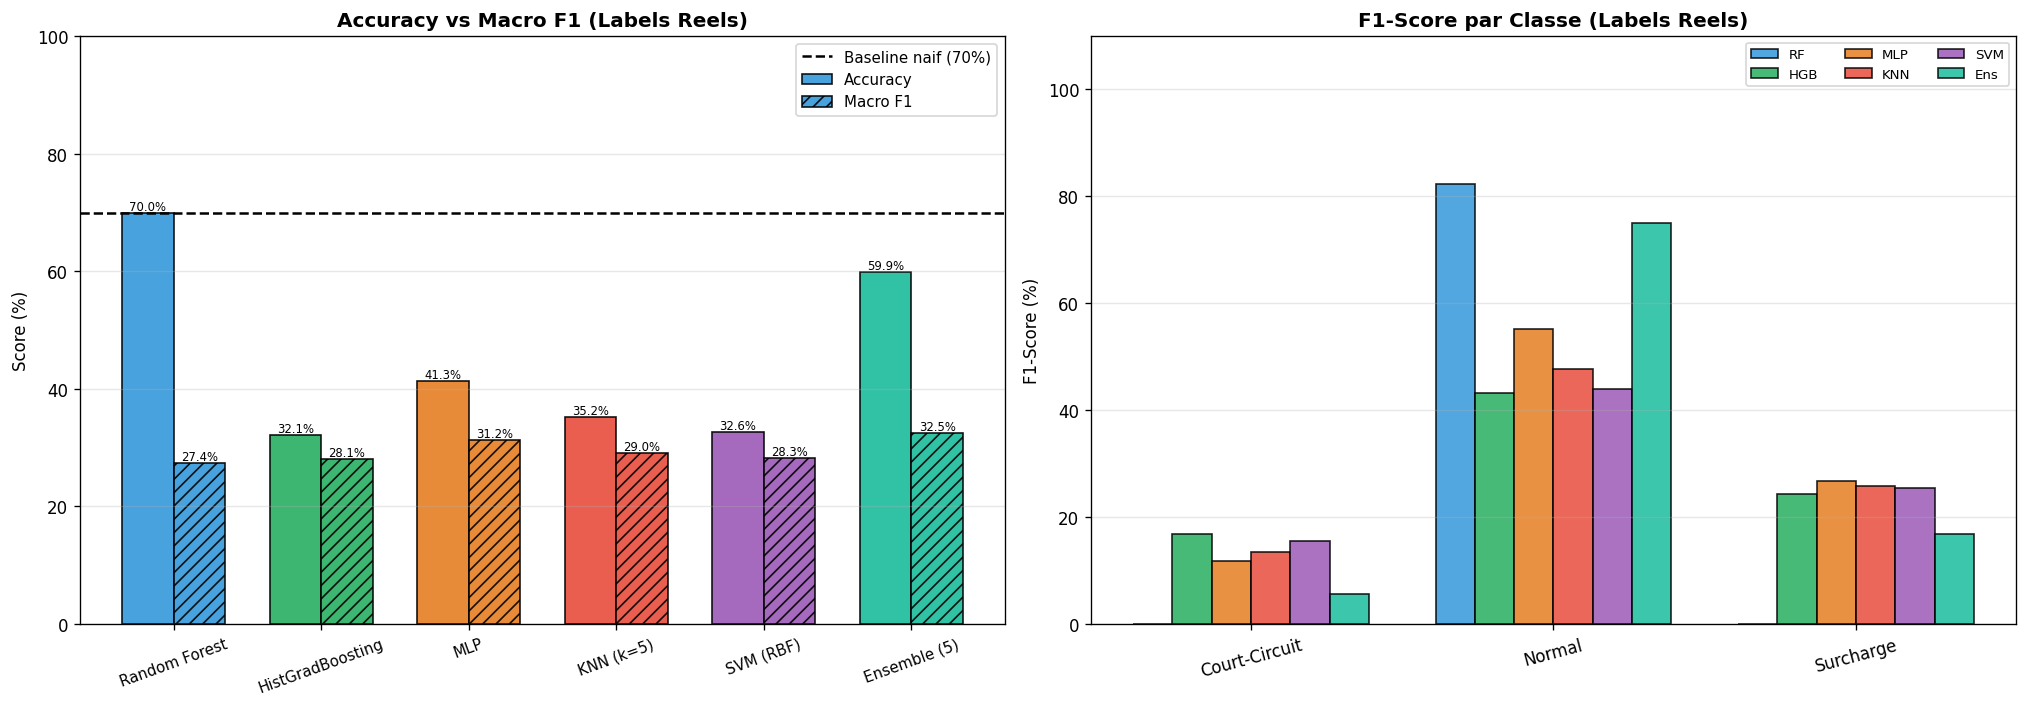

Figure sauvegardee : outputs_v6b/comparison.png


In [20]:
algo_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#1abc9c"]
algo_labels = list(results.index)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Graphique 1 : Accuracy vs Macro F1 ───────────────────────────────────────
x     = np.arange(len(results))
width = 0.35

b1 = axes[0].bar(x - width/2, results["Accuracy (%)"],
                 width, label="Accuracy",
                 color=algo_colors, edgecolor="black", alpha=0.9)
b2 = axes[0].bar(x + width/2, results["Macro F1 (%)"],
                 width, label="Macro F1",
                 color=[c+"88" for c in algo_colors],
                 edgecolor="black", alpha=0.9, hatch="///")

axes[0].axhline(69.97, color="black", linestyle="--",
                linewidth=1.5, label="Baseline naif (70%)")
axes[0].set_title("Accuracy vs Macro F1 (Labels Reels)",
                  fontweight="bold", fontsize=12)
axes[0].set_ylabel("Score (%)")
axes[0].set_ylim(0, 100)
axes[0].set_xticks(x)
axes[0].set_xticklabels(algo_labels, rotation=20, fontsize=9)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
for b in b1:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f"{b.get_height():.1f}%", ha="center", fontsize=7)
for b in b2:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f"{b.get_height():.1f}%", ha="center", fontsize=7)

# ── Graphique 2 : F1 par classe ───────────────────────────────────────────────
all_preds  = [y_pred_rf,y_pred_hgb,y_pred_mlp,y_pred_knn,y_pred_svm,y_pred_ens]
short_names= ["RF","HGB","MLP","KNN","SVM","Ens"]
w2 = 0.13
x2 = np.arange(len(CLASS_NAMES))

for j, (yp, name, col) in enumerate(zip(all_preds, short_names, algo_colors)):
    f1c = f1_score(y_test, yp, average=None, zero_division=0) * 100
    axes[1].bar(x2 + j*w2 - 2.5*w2, f1c, w2,
                label=name, color=col, edgecolor="black", alpha=0.85)

axes[1].set_title("F1-Score par Classe (Labels Reels)",
                  fontweight="bold", fontsize=12)
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(CLASS_NAMES, rotation=15, fontsize=10)
axes[1].legend(ncol=3, fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison.png")

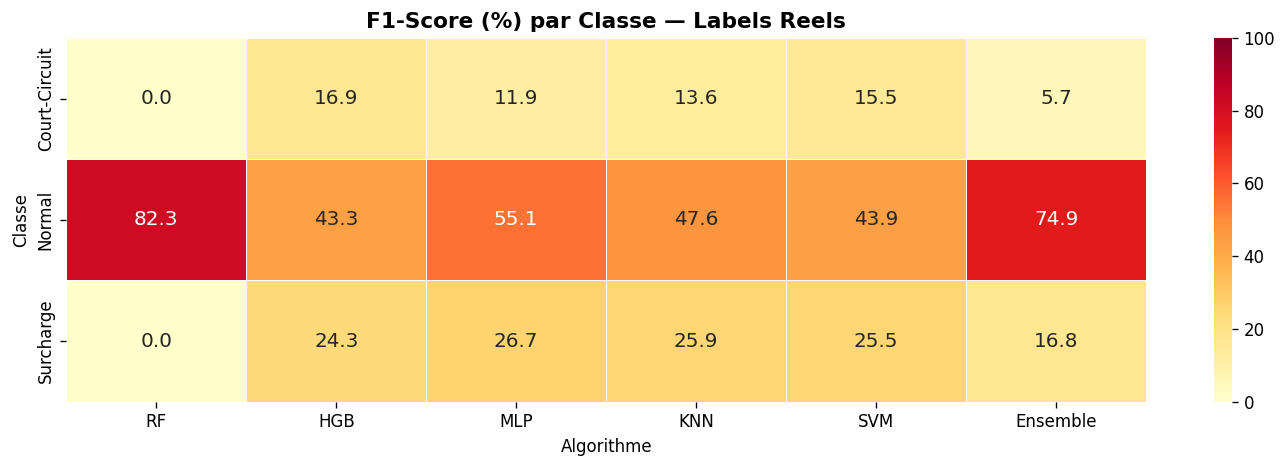

Figure sauvegardee : outputs_v6b/f1_heatmap.png


In [21]:
# Heatmap F1 par classe par algorithme
all_preds  = [y_pred_rf,y_pred_hgb,y_pred_mlp,y_pred_knn,y_pred_svm,y_pred_ens]
short_names= ["RF","HGB","MLP","KNN","SVM","Ensemble"]

f1_mat = {name: f1_score(y_test,yp,average=None,zero_division=0)*100
          for yp, name in zip(all_preds, short_names)}

df_heat = pd.DataFrame(f1_mat, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            annot_kws={"size": 12})
ax.set_title("F1-Score (%) par Classe — Labels Reels",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Algorithme"); ax.set_ylabel("Classe")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"f1_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/f1_heatmap.png")

---
## 16. Importance des Features (Random Forest)

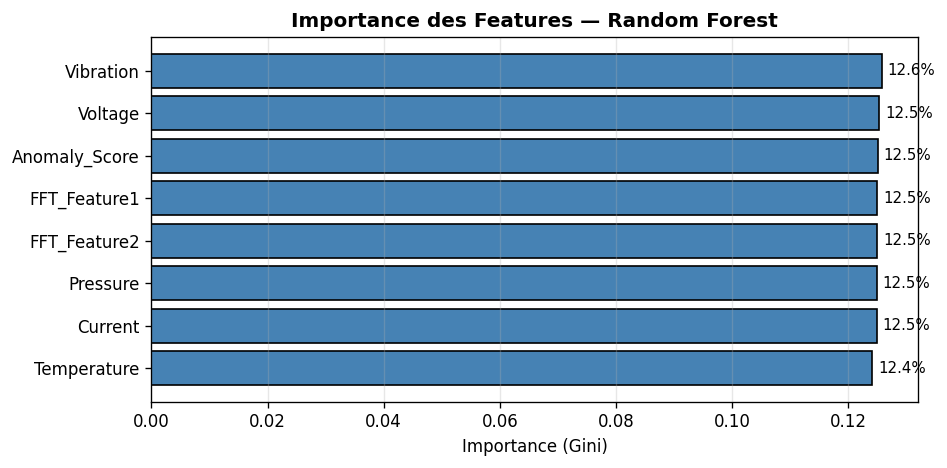

Figure sauvegardee : outputs_v6b/feature_importance.png


In [22]:
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh([FEATURE_COLS[i] for i in sorted_idx],
               importances[sorted_idx],
               color="steelblue", edgecolor="black")
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=9)
ax.set_title("Importance des Features — Random Forest", fontweight="bold")
ax.set_xlabel("Importance (Gini)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_importance.png")

---
## 17. Sauvegarde des Modeles

In [23]:
to_save = {
    "rf_model.joblib"         : rf,
    "hgb_model.joblib"        : hgb,
    "mlp_model.joblib"        : mlp,
    "knn_model.joblib"        : knn,
    "svm_model.joblib"        : svm,
    "scaler.joblib"           : scaler,
    "label_encoder.joblib"    : le,
    "feature_cols.joblib"     : FEATURE_COLS,
}
for fname, obj in to_save.items():
    joblib.dump(obj, os.path.join(OUTPUT_DIR, fname))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".joblib"):
        sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<35} ({sz/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs_v6b/' :
  feature_cols.joblib                 (0.1 KB)
  hgb_model.joblib                    (123.7 KB)
  knn_model.joblib                    (2053.8 KB)
  label_encoder.joblib                (0.5 KB)
  mlp_model.joblib                    (280.6 KB)
  rf_model.joblib                     (512148.4 KB)
  scaler.joblib                       (0.8 KB)
  svm_model.joblib                    (854.9 KB)


---
## 18. Prediction en Temps Reel

In [24]:
def predict_motor(
    temperature=50.0, vibration=80.0, pressure=200.0,
    voltage=220.0,    current=10.0,
    fft1=0.5,         fft2=0.5,
    anomaly_score=0.3,
    use_ensemble=True
):
    """
    Predit l etat du moteur (Normal / Surcharge / Court-Circuit).

    Parametres
    ----------
    temperature, vibration, pressure : grandeurs mecaniques / thermiques
    voltage, current                  : grandeurs electriques
    fft1, fft2                        : caracteristiques spectrales [0..1]
    anomaly_score                     : score d anomalie [0..1]
    use_ensemble                      : True = moyenne des 5 modeles
    """
    sample   = np.array([[temperature, vibration, pressure, voltage, current,
                          fft1, fft2, anomaly_score]], dtype=float)
    sample   = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample_s = scaler.transform(sample)

    if use_ensemble:
        proba = (rf.predict_proba(sample_s)  +
                 hgb.predict_proba(sample_s) +
                 mlp.predict_proba(sample_s) +
                 knn.predict_proba(sample_s) +
                 svm.predict_proba(sample_s)) / 5
        model_used = "Ensemble (5 modeles)"
    else:
        proba      = rf.predict_proba(sample_s)
        model_used = "Random Forest"

    pred_label = le.inverse_transform([np.argmax(proba)])[0]
    confiance  = np.max(proba) * 100

    print(f"  Capteurs   : T={temperature}C | Vib={vibration} | P={pressure}")
    print(f"               V={voltage}V | I={current}A | Anomaly={anomaly_score}")
    print(f"  Modele     : {model_used}")
    print(f"  Prediction : {pred_label}  (confiance {confiance:.1f}%)")
    print("  Probabilites :")
    for cls, prob in sorted(zip(CLASS_NAMES, proba[0]), key=lambda x:-x[1]):
        bar = "#" * int(prob * 30)
        print(f"    {cls:<15} = {prob*100:5.1f}%  {bar}")
    return pred_label

print("predict_motor() prete.")

predict_motor() prete.


In [25]:
print("=" * 65)

print("\nTEST 1 — Normal")
print("-" * 65)
predict_motor(temperature=50, vibration=80,  pressure=200,
              voltage=220,    current=10,    anomaly_score=0.3)

print("\nTEST 2 — Possible Surcharge")
print("-" * 65)
predict_motor(temperature=85, vibration=145, pressure=260,
              voltage=218,    current=16,    anomaly_score=0.75)

print("\nTEST 3 — Possible Court-Circuit")
print("-" * 65)
predict_motor(temperature=53, vibration=82,  pressure=205,
              voltage=208,    current=20,    anomaly_score=0.45)

print("=" * 65)


TEST 1 — Normal
-----------------------------------------------------------------
  Capteurs   : T=50C | Vib=80 | P=200
               V=220V | I=10A | Anomaly=0.3
  Modele     : Ensemble (5 modeles)
  Prediction : Normal  (confiance 48.4%)
  Probabilites :
    Normal          =  48.4%  ##############
    Court-Circuit   =  29.6%  ########
    Surcharge       =  22.0%  ######

TEST 2 — Possible Surcharge
-----------------------------------------------------------------
  Capteurs   : T=85C | Vib=145 | P=260
               V=218V | I=16A | Anomaly=0.75
  Modele     : Ensemble (5 modeles)
  Prediction : Normal  (confiance 37.1%)
  Probabilites :
    Normal          =  37.1%  ###########
    Surcharge       =  32.0%  #########
    Court-Circuit   =  30.9%  #########

TEST 3 — Possible Court-Circuit
-----------------------------------------------------------------
  Capteurs   : T=53C | Vib=82 | P=205
               V=208V | I=20A | Anomaly=0.45
  Modele     : Ensemble (5 modeles)
  Predi

---
## Recapitulatif — v6b vs v7

| | **v6b (ce notebook)** | **v7** |
|--|----------------------|--------|
| Labels | Reels du CSV | Generes par formules physiques |
| Mapping | Electrical Fault→CC, Overheating+Mechanical→Surcharge | z_I−z_V>1.5, 0.45z_I+...>0.6 |
| Accuracy RF | ~70% | ~98% |
| Macro F1 | ~27-31% | ~96% |
| Interpretation | Limite par qualite du dataset | Performant car les modeles apprennent les formules qu'on a utilisees pour labelliser |

### Pourquoi v6b plafonne a 70%

```
Test ANOVA : 7/8 features ont p > 0.05
=> Distributions identiques entre Normal, Surcharge, Court-Circuit
=> Les capteurs ne contiennent pas de signal pour distinguer les classes
=> Le dataset est synthetique avec labels independants des features
```

### Pipeline v6b

```
CSV (50 000 lignes)
    |
    v
Mapping 3 classes
    Fault_Status==0             -> Normal
    Electrical Fault            -> Court-Circuit
    Overheating + Mech. Failure -> Surcharge
    |
    v
8 features physiques (sans Normalized_* redondantes)
    |
    v
Split 80/20 + StandardScaler
    |
    +---> RF     class_weight='balanced'     (40k)
    +---> HGB    class_weight='balanced'     (40k)
    +---> MLP    undersample equilibre       (15k)
    +---> KNN    undersample equilibre       (15k)
    +---> SVM    undersample equilibre       ( 9k)
    +---> Ensemble Soft Voting (5 modeles)
```

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*